In [2]:
import os
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed
import networkx as nx
import matplotlib.pyplot as plt
from scipy.sparse import hstack, kron, eye, csc_matrix, block_diag
import time
import quimb as qu
import quimb.tensor as qtn
from quimb.tensor.fitting import tensor_network_distance
from ncon import ncon
import torch
import warnings
import torch.optim as optim
from quimb.tensor import tensor_split
import cotengra as ctg
import torch.nn as nn
from torch.optim.lr_scheduler import ReduceLROnPlateau

fsize = 24
tsize = 24

tdir = 'in'
major = 7.5
minor = 4.5

style = 'default'

plt.style.use(style)
plt.rcParams['text.usetex'] = False
plt.rcParams['font.size'] = fsize
plt.rcParams['legend.fontsize'] = tsize
plt.rcParams['xtick.direction'] = tdir
plt.rcParams['ytick.direction'] = tdir
plt.rcParams['xtick.major.size'] = major
plt.rcParams['xtick.minor.size'] = minor
plt.rcParams['ytick.major.size'] = major
plt.rcParams['ytick.minor.size'] = minor
plt.rcParams["figure.figsize"] = (16,9)
plt.rcParams['axes.grid']=False
plt.rcParams['grid.alpha'] = 0.25
#mpl.rcParams.update({"axes.grid" : True, "grid.alpha": 0.25})
plt.rcParams['figure.dpi'] = 400
plt.rcParams['text.usetex'] = True


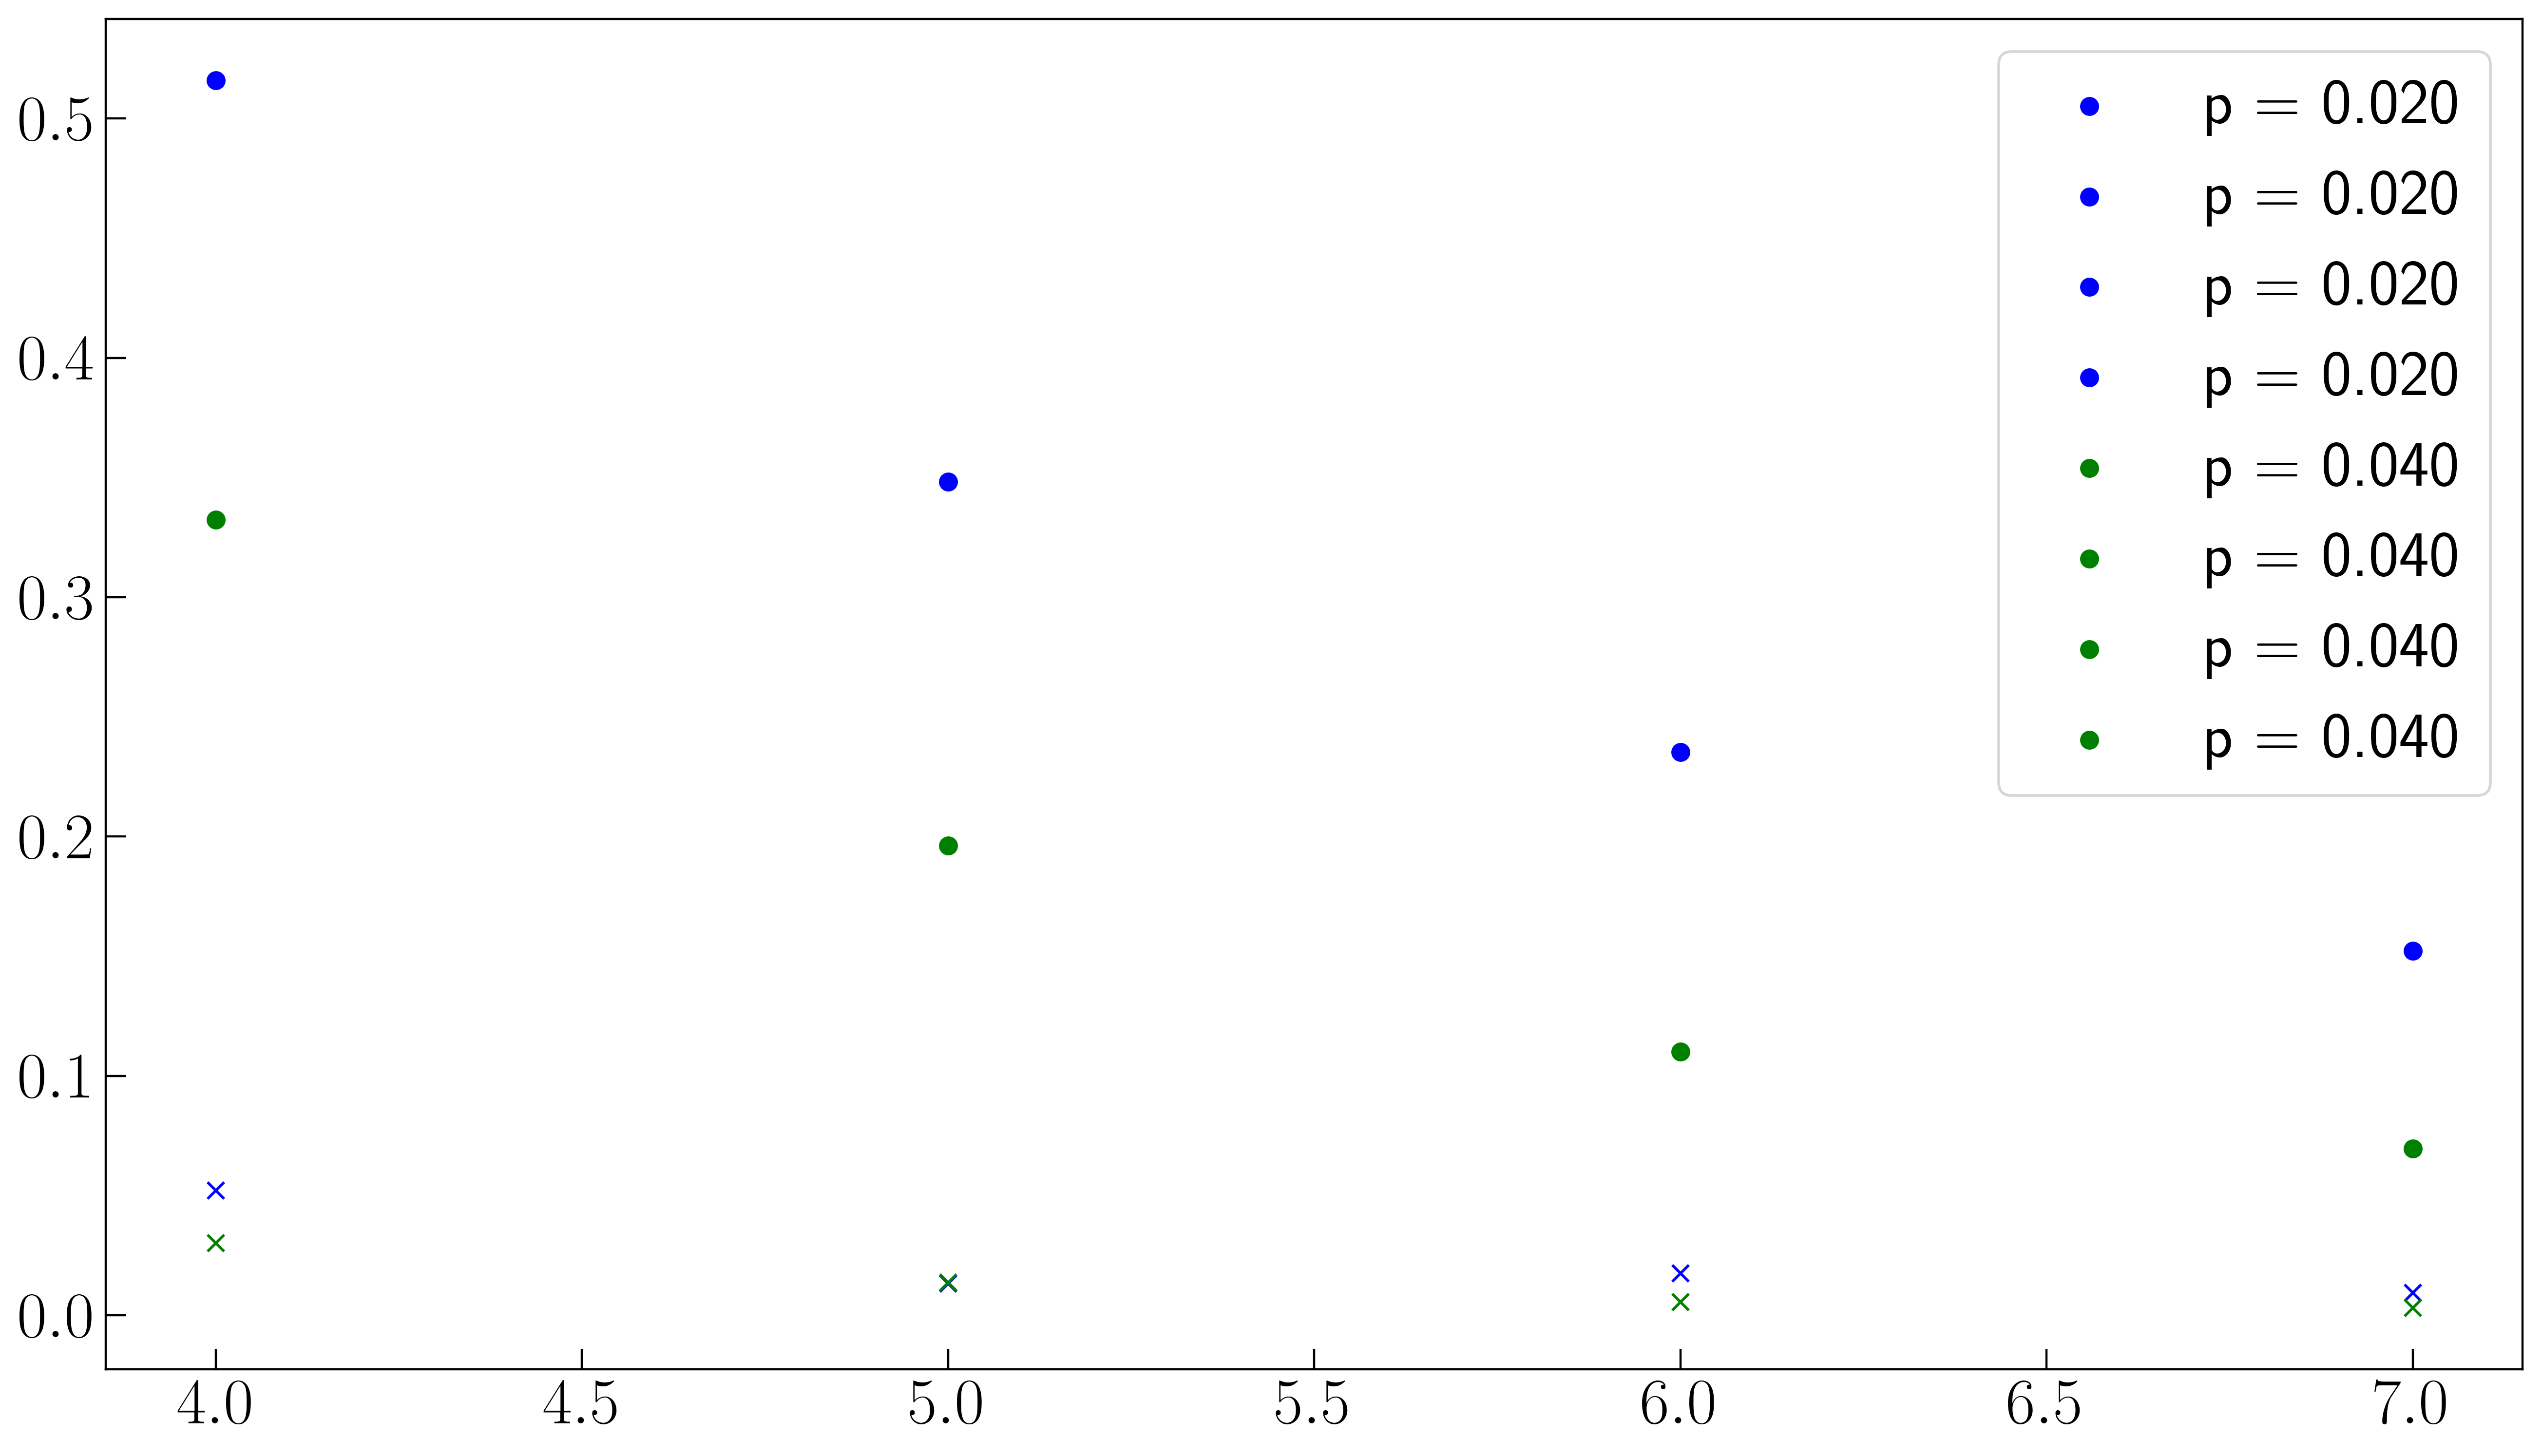

In [15]:
N = 30
T = 3
c_list = ['b', 'g', 'r', 'c', 'm', 'y', 'k']
fig, ax = plt.subplots(1, 1)
counter = 0
for depolarizing_name in [2, 4]:
    for L in [4, 5, 6, 7]:
        learning_loss_list = np.load(f"Depolarizing_N{N}_T{T}_L{L}_p_{depolarizing_name:03d}_learning_loss.npy")
        testing_loss = np.load(f"Depolarizing_N{N}_T{T}_L{L}_p_{depolarizing_name:03d}_testing_loss.npy")
        ax.scatter(L, min(learning_loss_list), c=c_list[counter], marker='o', label=f'p =  {depolarizing_name/100:.3f}')
        ax.plot(L, testing_loss, marker='x', c=c_list[counter])
    counter += 1
plt.legend(loc = "best")

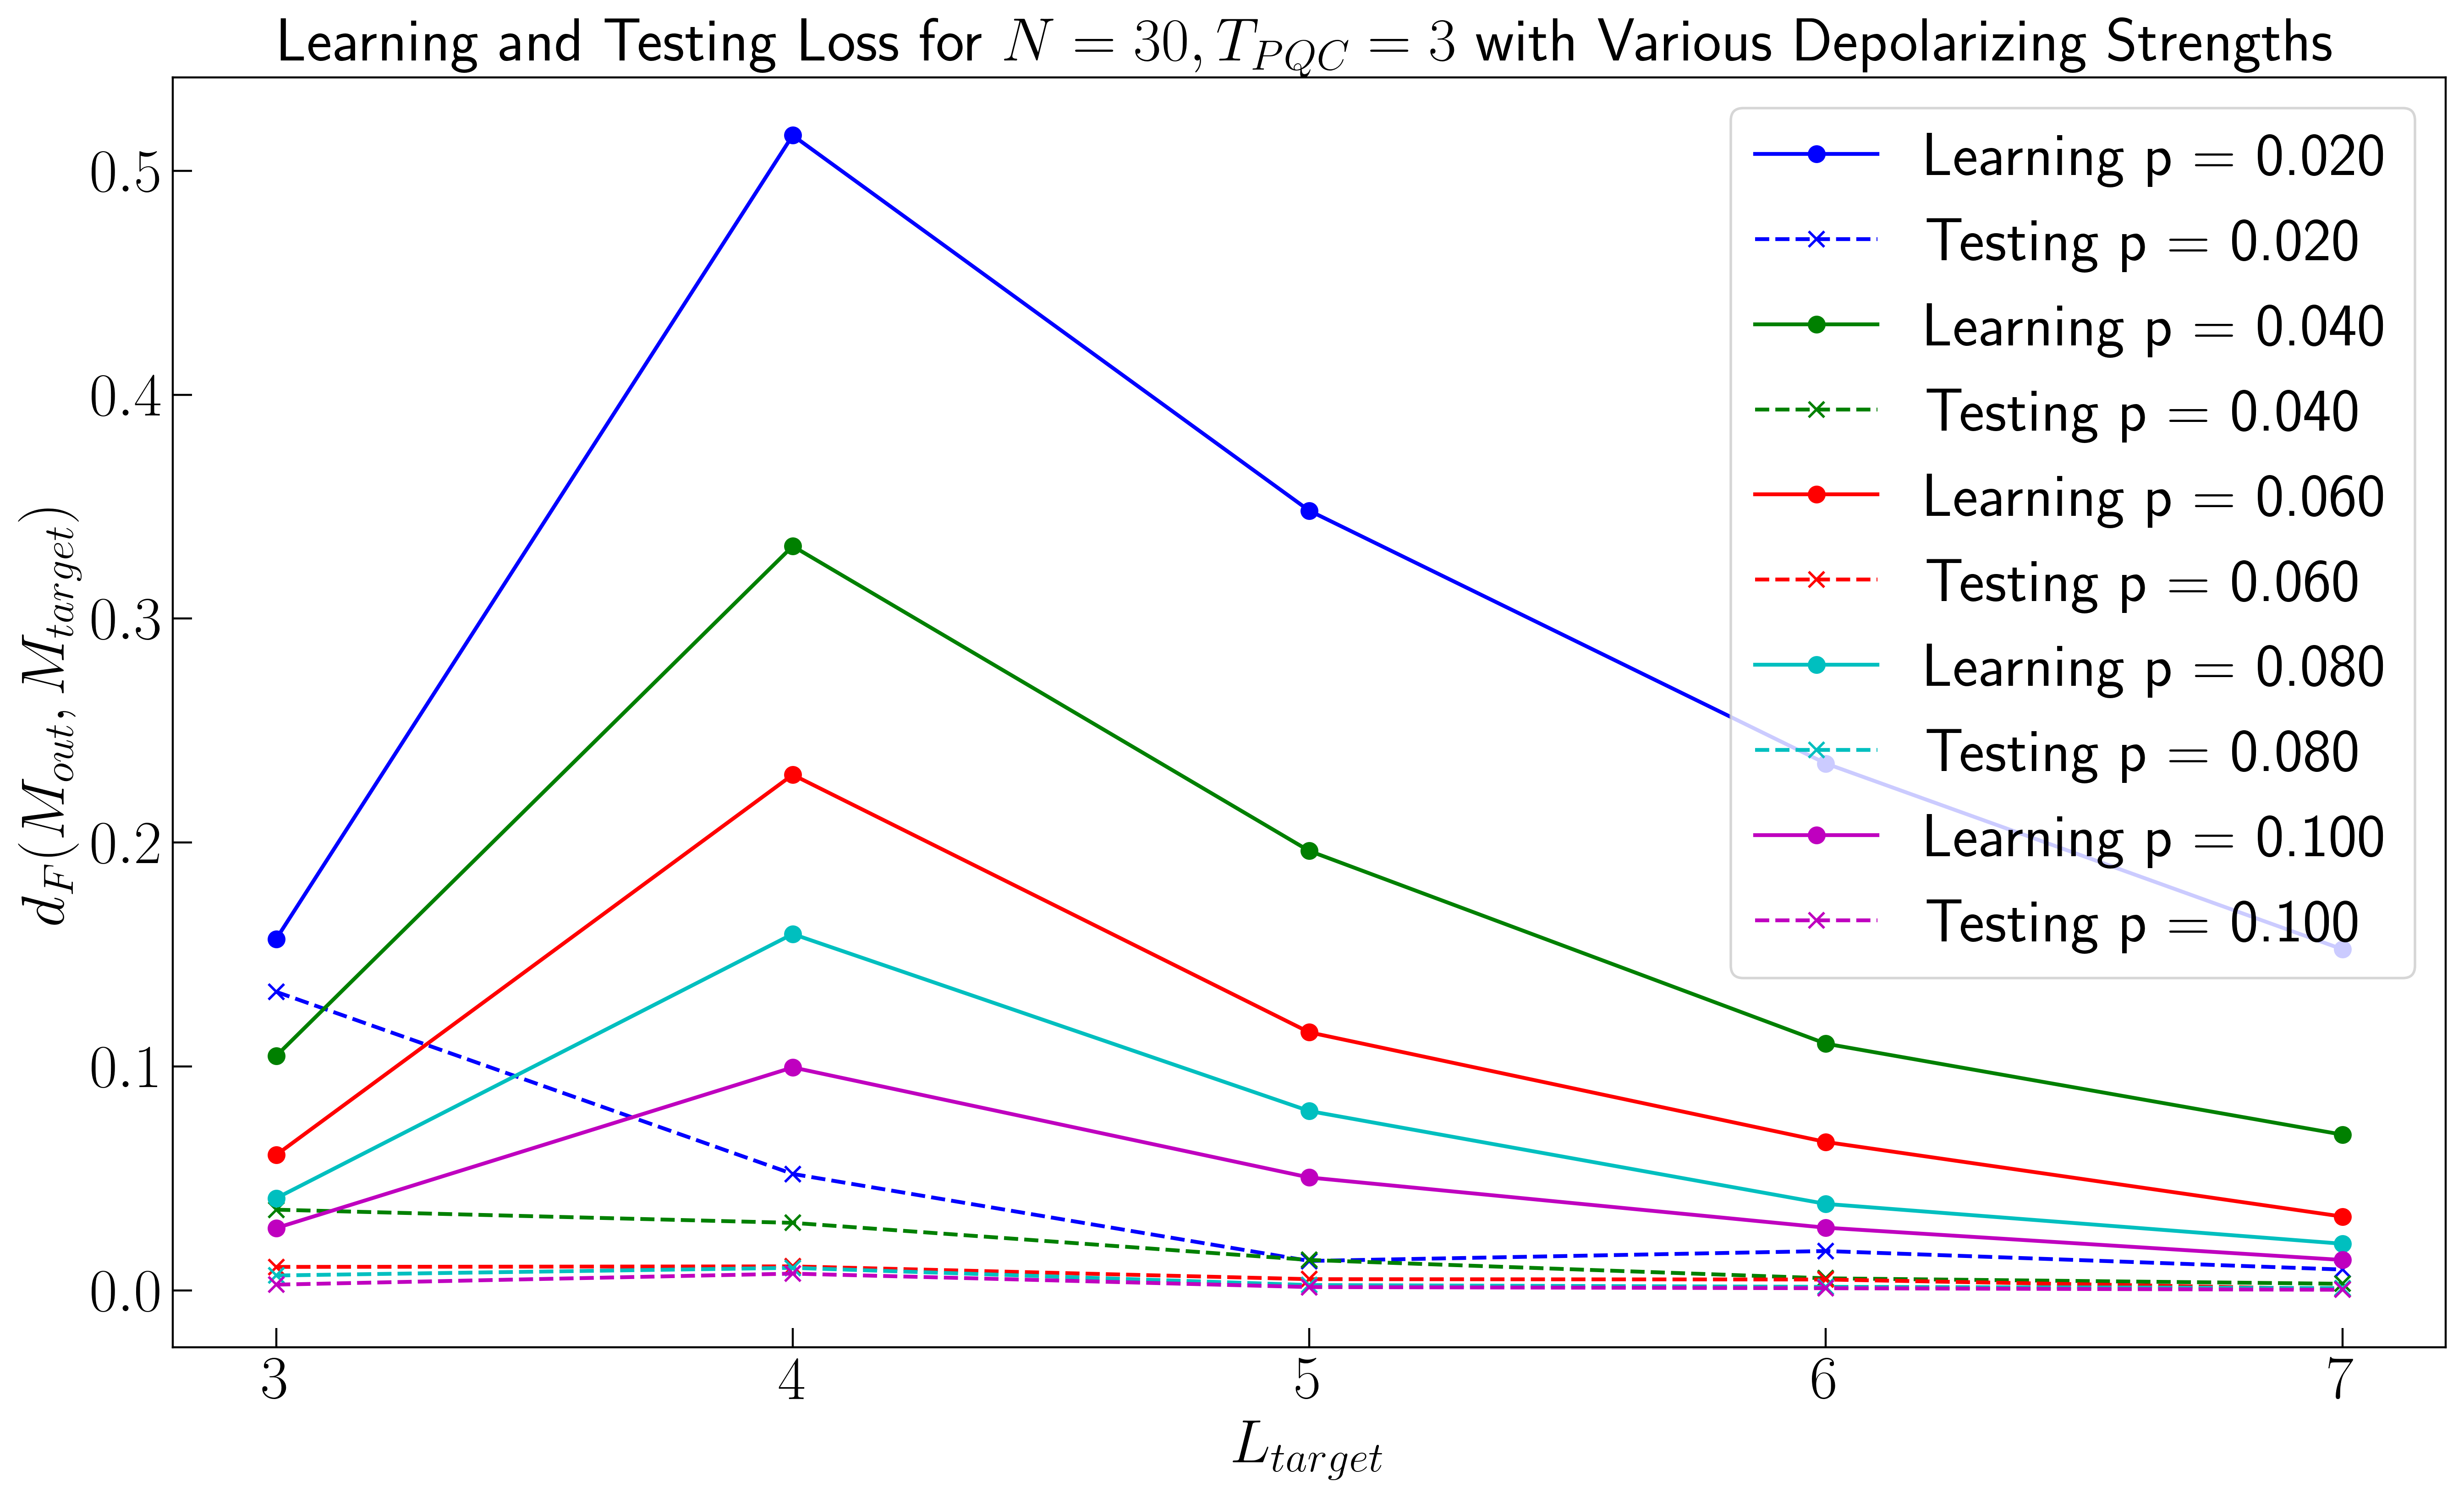

In [6]:
N = 30
T = 3
c_list = ['b', 'g', 'r', 'c', 'm', 'y', 'k']
fig, ax = plt.subplots(1, 1)

# Move the counter outside the primary loop so each 'p' gets a unique color
counter = 0

for depolarizing_name in [2, 4, 6, 8, 10]:
    # Initialize lists to collect coordinates for the line
    L_vals = []
    min_learning_vals = []
    testing_vals = []
    
    for L in [3, 4, 5, 6, 7]:
        # Load the data
        try:
            learning_loss_list = np.load(f"Depolarizing_N{N}_T{T}_L{L}_p_{depolarizing_name:03d}_learning_loss.npy")
            testing_loss = np.load(f"Depolarizing_N{N}_T{T}_L{L}_p_{depolarizing_name:03d}_testing_loss.npy")
            
            # Append the coordinates for each L
            L_vals.append(L)
            min_learning_vals.append(min(learning_loss_list))
            
            # Depending on how testing_loss is saved, you may need to scalarize it:
            # e.g., testing_vals.append(testing_loss.item()) if it's a 1-element Numpy array
            testing_vals.append(testing_loss)
        except:
            pass
        
    # Plot the collected points as a connected line
    # linestyle='-' and marker='o' draws both the lines and the points respectively
    ax.plot(L_vals, min_learning_vals, c=c_list[counter], marker='o', linestyle='-', label=f'Learning p = {depolarizing_name/100:.3f}')
    ax.plot(L_vals, testing_vals, c=c_list[counter], marker='x', linestyle='--', label=f'Testing p = {depolarizing_name/100:.3f}')
    
    counter += 1

# Display the legend
ax.legend()
ax.set_title(r'Learning and Testing Loss for $N=30, T_{PQC}=3$ with Various Depolarizing Strengths', fontsize=24)
ax.set_ylabel(r'$d_F(M_{out}, M_{target})$', fontsize=24)
ax.set_xticks(np.arange(3, 8))
ax.set_xlabel(r'$L_{target}$', fontsize=24)
plt.savefig("Figures/Depolarizing_ChangeT_N_L_p_30_3_all.pdf", dpi = 800)
plt.show()
